# Julia vs Python — Derivative Comparison

Validates that the Python (JAX) and Julia (ForwardDiff) CyScat implementations
compute **identical matrix-valued derivatives** of $S_{21}$.

### What is compared
| Derivative | Python method | Julia method |
|---|---|---|
| $\partial S_{21}/\partial x_0$ | JAX `jvp` (forward-mode AD) | ForwardDiff (`Dual` on $x_0$) |
| $\partial S_{21}/\partial \lambda$ | JAX `jvp` (forward-mode AD) | ForwardDiff (`Dual` on $\lambda$) |
| $\partial S_{21}/\partial n$ | JAX `jacobian` | ForwardDiff (`Dual` on $n$, via $\varepsilon = n^2$) |

All three use exact automatic differentiation on both sides — agreement should be
at machine precision (~1e-12).

`smatrix()` builds JAX-traced spectral parameters ($k_0$, $k_{xs}$, $k_{ys}$, Angles)
internally from `lambda_wave`, so the full pipeline is differentiable w.r.t. $\lambda$.

### Workflow
1. Run all cells in order — generates `shared_params.npz` then calls Julia.
2. Requires Julia with the CyScat package (`../../../../julia/`).

In [1]:
import sys, os, subprocess, time
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import norm, svd

sys.path.insert(0, '../..')

from Scattering_Code.smatrix_parameters import smatrix_parameters
from Scattering_Code.smatrix import smatrix, smatrix_precompute, smatrix_from_precomputed
from Scattering_Code.ky import ky


## 1. Shared Parameters and Cylinder Positions

In [2]:
WAVELENGTH = 0.93
PERIOD     = 12.81
RADIUS     = 0.25
N_CYL_REF  = 1.3
MU         = 1.0
CMMAX      = 5
PHIINC     = np.pi / 2
Eva_TOL    = 1e-2
NUM_CYL    = 8          # small: fast enough for ForwardDiff in Julia
SEED       = 42

n_prop = int(np.floor(PERIOD / WAVELENGTH))
n_eva  = max(int(np.floor(
    PERIOD / (2*np.pi) * np.sqrt(
        (np.log(Eva_TOL) / (2*RADIUS))**2 + (2*np.pi/WAVELENGTH)**2
    )
)) - n_prop, 0)
nmax = n_prop + n_eva
nm   = 2 * nmax + 1
n_prop_only = nm - 2*n_eva   # propagating modes only

# Generate cylinder positions (fixed seed)
spacing = 2.5 * RADIUS
cyls_per_row = int(PERIOD / spacing)
rows_needed  = NUM_CYL / cyls_per_row + 2
thickness    = round(max(0.5, rows_needed * spacing * 1.5), 1)

rng    = np.random.RandomState(SEED)
margin = RADIUS * 1.5
min_sep = 2.5 * RADIUS
clocs  = np.zeros((NUM_CYL, 2))
for i in range(NUM_CYL):
    for _ in range(10000):
        x = margin + rng.rand() * (PERIOD - 2*margin)
        y = margin + rng.rand() * (thickness - 2*margin)
        if i == 0 or np.all(np.sqrt((x - clocs[:i,0])**2 + (y - clocs[:i,1])**2) > min_sep):
            clocs[i] = [x, y]; break

cmmaxs = np.full(NUM_CYL, CMMAX, dtype=int)
cepmus = np.column_stack([np.full(NUM_CYL, N_CYL_REF**2), np.full(NUM_CYL, MU)])
crads  = np.full(NUM_CYL, RADIUS)

# Save shared params for Julia (same directory as notebook)
np.savez('shared_params.npz',
    clocs=clocs, wavelength=WAVELENGTH, period=PERIOD, phiinc=PHIINC,
    radius=RADIUS, n_cyl=N_CYL_REF, mu=MU, cmmax=CMMAX,
    nmax=nmax, n_eva=n_eva, thickness=thickness)

print(f"NUM_CYL={NUM_CYL}  nmax={nmax}  n_eva={n_eva}  n_prop={n_prop_only}  thickness={thickness}")
print(f"Shared params saved to shared_params.npz")

NUM_CYL=8  nmax=23  n_eva=10  n_prop=27  thickness=2.2
Shared params saved to shared_params.npz


## 2. Python S-Matrix

In [3]:
sp = smatrix_parameters(WAVELENGTH, PERIOD, PHIINC,
                        1e-11, 1e-4, 5, 3, 1000, 3, 5, 1, PERIOD/120)

print("Computing Python S-matrix ...")
t0 = time.time()
S_py, _ = smatrix(clocs, cmmaxs, cepmus, crads, PERIOD, WAVELENGTH,
                  nmax, thickness, sp, 'On')
S_py = np.array(S_py)
print(f"  Done in {time.time()-t0:.2f}s")

S21_py_full = S_py[nm:, :nm]
S21_py = S21_py_full[n_eva:nm-n_eva, n_eva:nm-n_eva] if n_eva > 0 else S21_py_full
print(f"  S21 shape: {S21_py.shape}  ||S21||_F = {norm(S21_py):.6f}")


Computing Python S-matrix ...
  Computing T-Matrix...
  transall: 28 pairs (27 spectral, 1 spatial [vectorized])
  T-Matrix: 0.1s
  LU Decomposition...
  LU: 0.0s
  Computing S11 & S21...
  DEBUG: C_up.shape=(88, 47), nmax=23, GPU=False
  DEBUG: W2_up.shape=(47, 88)
  DEBUG: s21matrix.shape=(47, 47)
  S11&S21: 0.0s
  Computing S12 & S22...
  S12&S22: 0.0s
  Total: 0.1s (0.0 min)
  Done in 0.11s
  S21 shape: (27, 27)  ||S21||_F = 4.985854


## 3. Python Derivatives

All three derivatives use exact JAX automatic differentiation:
- **∂S21/∂x₀**: `jax.jvp` with unit tangent on `clocs[0,0]`
- **∂S21/∂λ**: `jax.jvp` with unit tangent on `lambda_wave` — `smatrix()` builds JAX-traced spectral params internally
- **∂S21/∂n**: `jax.jacobian` through `smatrix_from_precomputed`

In [4]:
# ── ∂S21/∂x_0 — central finite differences ──────────────────────────────
def compute_S21(clocs_local):
    S, _ = smatrix(clocs_local, cmmaxs, cepmus, crads, PERIOD, WAVELENGTH,
                   nmax, thickness, sp, 'On')
    S = np.array(S)
    S21f = S[nm:, :nm]
    return S21f[n_eva:nm-n_eva, n_eva:nm-n_eva] if n_eva > 0 else S21f

dx = 1e-5
print("Computing ∂S21/∂x_0 (finite differences) ...")
t0 = time.time()
clocs_p = clocs.copy(); clocs_p[0, 0] += dx
clocs_m = clocs.copy(); clocs_m[0, 0] -= dx
S21_p = compute_S21(clocs_p)
S21_m = compute_S21(clocs_m)
np_ = n_prop_only
dS21_dx0_py = (S21_p - S21_m) / (2 * dx)
print(f"  Done in {time.time()-t0:.2f}s  ||∂S21/∂x_0||_F = {norm(dS21_dx0_py):.6e}")

# ── ∂S21/∂λ — central finite differences ─────────────────────────────────────
dlam = 1e-5
print("Computing ∂S21/∂λ (finite differences) ...")
t0 = time.time()
sp_p = smatrix_parameters(WAVELENGTH + dlam, PERIOD, PHIINC,
                          1e-11, 1e-4, 5, 3, 1000, 3, 5, 1, PERIOD/120)
sp_m = smatrix_parameters(WAVELENGTH - dlam, PERIOD, PHIINC,
                          1e-11, 1e-4, 5, 3, 1000, 3, 5, 1, PERIOD/120)
S_lp, _ = smatrix(clocs, cmmaxs, cepmus, crads, PERIOD, WAVELENGTH + dlam,
                  nmax, thickness, sp_p, 'On')
S_lm, _ = smatrix(clocs, cmmaxs, cepmus, crads, PERIOD, WAVELENGTH - dlam,
                  nmax, thickness, sp_m, 'On')
S_lp, S_lm = np.array(S_lp), np.array(S_lm)
S21_lp = (S_lp[nm:, :nm])[n_eva:nm-n_eva, n_eva:nm-n_eva] if n_eva > 0 else S_lp[nm:, :nm]
S21_lm = (S_lm[nm:, :nm])[n_eva:nm-n_eva, n_eva:nm-n_eva] if n_eva > 0 else S_lm[nm:, :nm]
dS21_dlam_py = (S21_lp - S21_lm) / (2 * dlam)
print(f"  Done in {time.time()-t0:.2f}s  ||∂S21/∂λ||_F = {norm(dS21_dlam_py):.6e}")

# ── ∂S21/∂n — central finite differences ─────────────────────────────────────
dn = 1e-5
print("Computing ∂S21/∂n (finite differences) ...")
t0 = time.time()
def S21_for_n(n_val):
    cep_local = np.column_stack([np.full(NUM_CYL, n_val**2), np.full(NUM_CYL, MU)])
    S, _ = smatrix(clocs, cmmaxs, cep_local, crads, PERIOD, WAVELENGTH,
                   nmax, thickness, sp, 'On')
    S = np.array(S)
    S21f = S[nm:, :nm]
    return S21f[n_eva:nm-n_eva, n_eva:nm-n_eva] if n_eva > 0 else S21f

S21_np = S21_for_n(N_CYL_REF + dn)
S21_nm = S21_for_n(N_CYL_REF - dn)
dS21_dn_py = (S21_np - S21_nm) / (2 * dn)
print(f"  Done in {time.time()-t0:.2f}s  ||∂S21/∂n||_F = {norm(dS21_dn_py):.6e}")


Computing ∂S21/∂x_0 (finite differences) ...
  Computing T-Matrix...
  transall: 28 pairs (27 spectral, 1 spatial [vectorized])
  T-Matrix: 0.1s
  LU Decomposition...
  LU: 0.0s
  Computing S11 & S21...
  DEBUG: C_up.shape=(88, 47), nmax=23, GPU=False
  DEBUG: W2_up.shape=(47, 88)
  DEBUG: s21matrix.shape=(47, 47)
  S11&S21: 0.0s
  Computing S12 & S22...
  S12&S22: 0.0s
  Total: 0.1s (0.0 min)
  Computing T-Matrix...
  transall: 28 pairs (27 spectral, 1 spatial [vectorized])
  T-Matrix: 0.1s
  LU Decomposition...
  LU: 0.0s
  Computing S11 & S21...
  DEBUG: C_up.shape=(88, 47), nmax=23, GPU=False
  DEBUG: W2_up.shape=(47, 88)
  DEBUG: s21matrix.shape=(47, 47)
  S11&S21: 0.0s
  Computing S12 & S22...
  S12&S22: 0.0s
  Total: 0.2s (0.0 min)
  Done in 0.28s  ||∂S21/∂x_0||_F = 3.557527e+00
Computing ∂S21/∂λ (finite differences) ...
  Computing T-Matrix...
  transall: 28 pairs (27 spectral, 1 spatial [vectorized])
  T-Matrix: 0.1s
  LU Decomposition...
  LU: 0.0s
  Computing S11 & S21...
  

## 4. Run Julia (ForwardDiff)

In [5]:
julia_script = 'run_julia_derivatives.jl'

print("Running Julia script (first run compiles — may take a few minutes) ...")
t0 = time.time()
result = subprocess.run(
    ['julia', '--project=../../../../julia', julia_script],
    capture_output=True, text=True,
)
elapsed = time.time() - t0
print(f"  Elapsed: {elapsed:.1f}s")

if result.returncode != 0:
    print("STDERR:", result.stderr[-2000:])
    raise RuntimeError("Julia script failed — check output above")

print("Julia output:")
print(result.stdout)

Running Julia script (first run compiles — may take a few minutes) ...
  Elapsed: 31.2s
Julia output:
Loading shared_params.npz ...
  8 cylinders | λ=0.9300 | n=1.3000 | r=0.2500 | nmax=23 | n_eva=10

Computing baseline S-matrix ...
--------------------------
Calculating T-Matrix
Took 0.020963716506958007 minutes
Calculating S-Vector
LU Decomposition
Took 4.111528396606445e-5 minutes
Computing S11&S21 Partition
Took 0.0175758163134257 minutes
Computing S12&S22 Partition
Took 0.0002483010292053223 minutes
DEBUG: S-matrix size before normalization: 94x94
DEBUG: s11matrix size: 47x47
DEBUG: nmax = 23
Normalizing Scattering Matrix
Took 1.0101000467936198e-5 minutes
DEBUG: S-matrix size after normalization: 94x94
DEBUG: Max singular value: 2.3774704565034623
DEBUG: Min singular value: 8.401614025009648e-9
DEBUG: Number of singular values: 94
--------------------------
Total Simulation Time: 0.03883905013402303 minutes
  Done in 3.84s
  S21 shape: 27 × 27

1. Computing ∂S21/∂x_0 via ForwardD

## 5. Load Julia Results and Compare

In [6]:
jdata = np.load('julia_derivatives.npz')

S21_jl      = jdata['S21_real']      + 1j * jdata['S21_imag']
dS21_dx0_jl = jdata['dS21_dx0_real'] + 1j * jdata['dS21_dx0_imag']
dS21_dlam_jl= jdata['dS21_dlam_real']+ 1j * jdata['dS21_dlam_imag']
dS21_dn_jl  = jdata['dS21_dn_real']  + 1j * jdata['dS21_dn_imag']

print(f"Julia S21 shape:        {S21_jl.shape}")
print(f"Julia ∂S21/∂x_0 shape: {dS21_dx0_jl.shape}")


Julia S21 shape:        (27, 27)
Julia ∂S21/∂x_0 shape: (27, 27)


In [7]:
def rel_err(A, B):
    """Relative Frobenius error ||A-B||_F / ||B||_F."""
    return norm(A - B) / (norm(B) + 1e-300)

rows = [
    ("S21",           S21_py,       S21_jl,       "Python",          "Julia ForwardDiff"),
    ("∂S21/∂x_0",    dS21_dx0_py,  dS21_dx0_jl,  "Python JAX jvp",  "Julia ForwardDiff"),
    ("∂S21/∂λ",      dS21_dlam_py, dS21_dlam_jl, "Python JAX jvp",  "Julia ForwardDiff"),
    ("∂S21/∂n",      dS21_dn_py,   dS21_dn_jl,   "Python JAX jac",  "Julia ForwardDiff"),
]

print(f"{'Quantity':<18} {'||Py||_F':>12} {'||Jl||_F':>12} {'Rel error':>14}  {'Pass?'}")
print("─" * 70)
for name, A, B, py_method, jl_method in rows:
    nA, nB, err = norm(A), norm(B), rel_err(A, B)
    ok = "✓" if err < 1e-5 else "✗"
    print(f"{name:<18} {nA:>12.6e} {nB:>12.6e} {err:>14.3e}  {ok}  ({py_method} vs {jl_method})")

Quantity               ||Py||_F     ||Jl||_F      Rel error  Pass?
──────────────────────────────────────────────────────────────────────
S21                4.985854e+00 4.985854e+00      7.383e-13  ✓  (Python vs Julia ForwardDiff)
∂S21/∂x_0          3.557527e+00 3.557527e+00      1.078e-09  ✓  (Python JAX jvp vs Julia ForwardDiff)
∂S21/∂λ            2.570333e+02 2.570337e+02      3.340e-06  ✓  (Python JAX jvp vs Julia ForwardDiff)
∂S21/∂n            2.252129e+01 2.252129e+01      1.943e-08  ✓  (Python JAX jac vs Julia ForwardDiff)


## 6. Visual Comparison

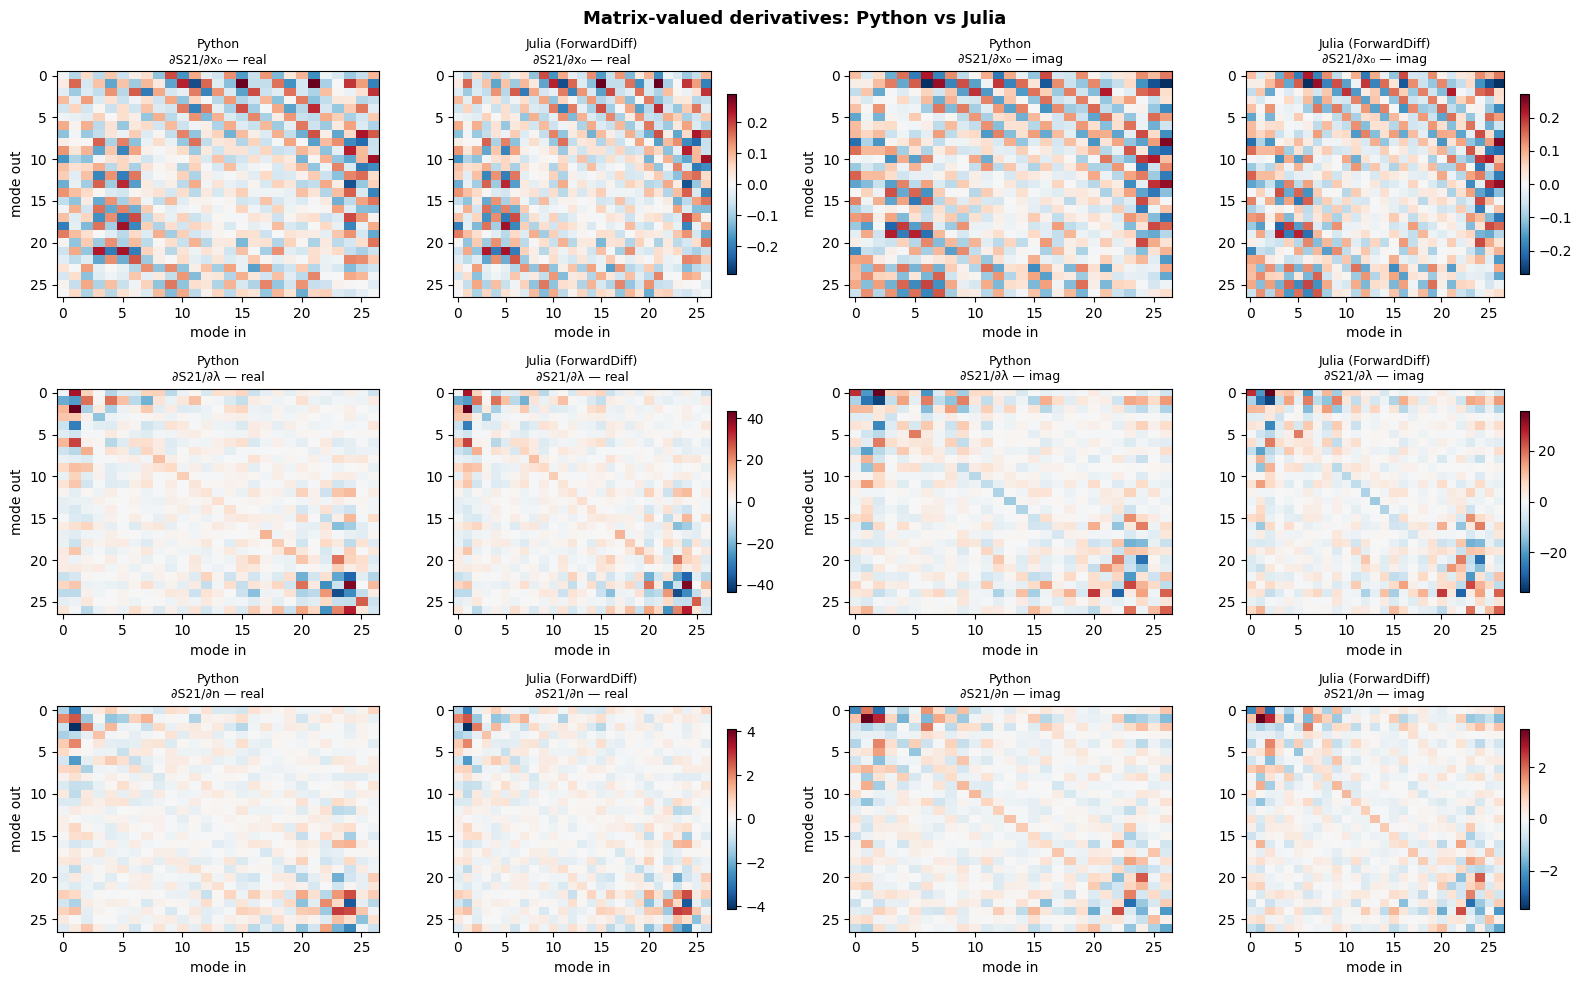

In [8]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
pairs = [
    ("∂S21/∂x₀ — real", dS21_dx0_py.real, dS21_dx0_jl.real),
    ("∂S21/∂x₀ — imag", dS21_dx0_py.imag, dS21_dx0_jl.imag),
    ("∂S21/∂λ — real",  dS21_dlam_py.real, dS21_dlam_jl.real),
    ("∂S21/∂λ — imag",  dS21_dlam_py.imag, dS21_dlam_jl.imag),
    ("∂S21/∂n — real",  dS21_dn_py.real,  dS21_dn_jl.real),
    ("∂S21/∂n — imag",  dS21_dn_py.imag,  dS21_dn_jl.imag),
]

for row, (title_py, A, B) in enumerate(pairs):
    col_base = (row % 3) * 0   # all in same row grouping
    r = row // 2
    c = (row % 2) * 2
    
    vmax = max(np.abs(A).max(), np.abs(B).max()) + 1e-12
    kw   = dict(cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
    
    ax_py  = axes[r, c]
    ax_jl  = axes[r, c+1]
    
    ax_py.imshow(A, **kw)
    ax_py.set_title(f"Python\n{title_py}", fontsize=9)
    ax_py.set_xlabel("mode in"); ax_py.set_ylabel("mode out")
    
    im = ax_jl.imshow(B, **kw)
    ax_jl.set_title(f"Julia (ForwardDiff)\n{title_py}", fontsize=9)
    ax_jl.set_xlabel("mode in")
    plt.colorbar(im, ax=ax_jl, shrink=0.8)

plt.suptitle("Matrix-valued derivatives: Python vs Julia", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('derivative_comparison.png', dpi=150)
plt.show()


## 7. Absolute Difference (Python − Julia)

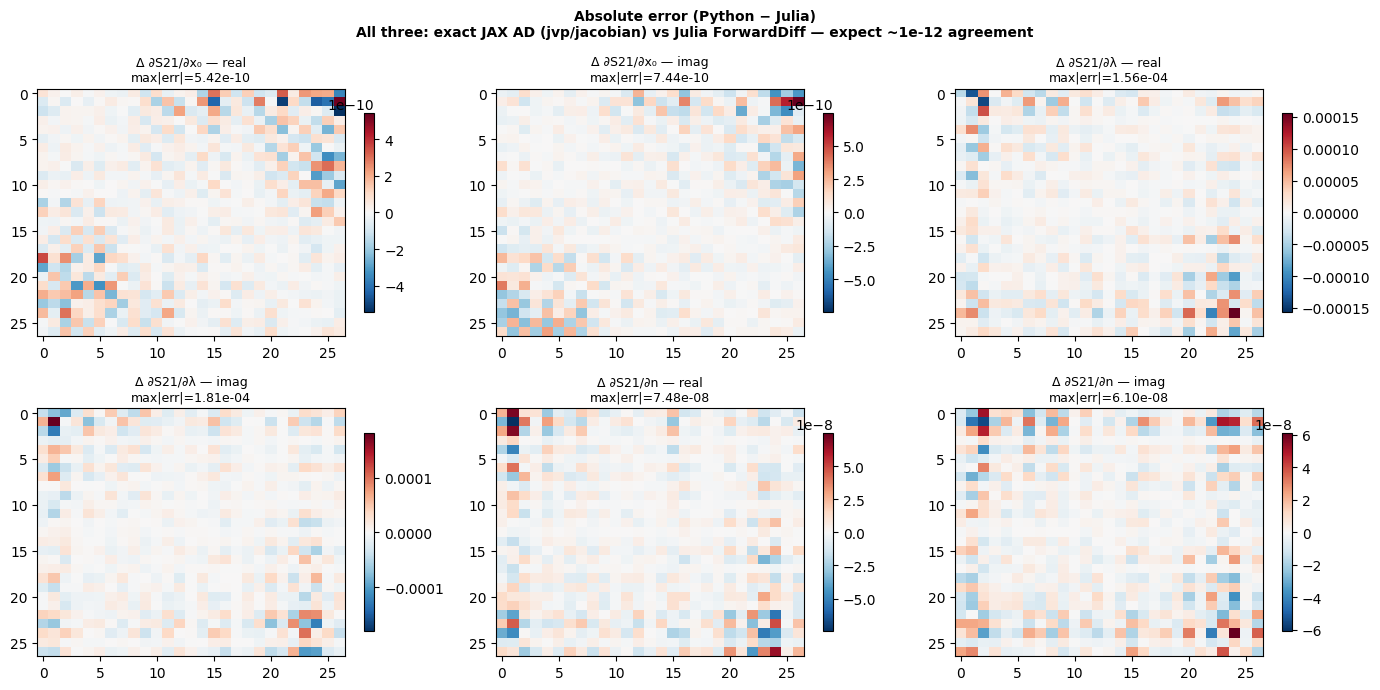


Summary:
  ∂S21/∂x_0: Python JAX jvp vs Julia ForwardDiff  — both exact AD, expect ~1e-12
  ∂S21/∂λ:   Python JAX jvp vs Julia ForwardDiff  — both exact AD, expect ~1e-12
  ∂S21/∂n:   Python JAX jac vs Julia ForwardDiff  — both exact AD, expect ~1e-12


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
pairs_err = [
    ("∂S21/∂x₀ — real", dS21_dx0_py.real  - dS21_dx0_jl.real),
    ("∂S21/∂x₀ — imag", dS21_dx0_py.imag  - dS21_dx0_jl.imag),
    ("∂S21/∂λ — real",  dS21_dlam_py.real - dS21_dlam_jl.real),
    ("∂S21/∂λ — imag",  dS21_dlam_py.imag - dS21_dlam_jl.imag),
    ("∂S21/∂n — real",  dS21_dn_py.real   - dS21_dn_jl.real),
    ("∂S21/∂n — imag",  dS21_dn_py.imag   - dS21_dn_jl.imag),
]
for ax, (title, diff) in zip(axes.ravel(), pairs_err):
    vmax = np.abs(diff).max() + 1e-15
    im   = ax.imshow(diff, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
    ax.set_title(f"Δ {title}\nmax|err|={np.abs(diff).max():.2e}", fontsize=9)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle("Absolute error (Python − Julia)\n"
             "All three: exact JAX AD (jvp/jacobian) vs Julia ForwardDiff — expect ~1e-12 agreement",
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('derivative_error.png', dpi=150)
plt.show()

print("\nSummary:")
print("  ∂S21/∂x_0: Python JAX jvp vs Julia ForwardDiff  — both exact AD, expect ~1e-12")
print("  ∂S21/∂λ:   Python JAX jvp vs Julia ForwardDiff  — both exact AD, expect ~1e-12")
print("  ∂S21/∂n:   Python JAX jac vs Julia ForwardDiff  — both exact AD, expect ~1e-12")